# Gradient Boosting Trees

This notebook looks at Stochastic Gradient Descent Classifier (SGDClassifier) as well as XGBoostClassifier in seeing if they can better the decision trees and ensemble methods from the prior notebook.

In [1]:
%%capture
%pip install hpsklearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils
from utils import *
import xgboost as XGB
from sklearn.ensemble import GradientBoostingClassifier as SGD
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, roc_curve
warnings.filterwarnings(action='ignore')

In [ ]:
df = pd.read_parquet('../../data/ACME-HappinessSurvey2020_shrunk.parquet')
df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [5]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=seed, test_size=.20
)

In [6]:
y_train.mean(), y_test.mean()

(np.float64(0.55), np.float64(0.5384615384615384))

### Stochastic Gradient Descent

In [7]:
sgd = SGD(random_state=seed, max_depth=3, n_estimators=100, learning_rate=.1)
sgd.fit(X_train, y_train)

return_scores(sgd, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.910000,0.945455,0.896552
Test,0.576923,0.428571,0.666667


In [14]:
from hpsklearn import HyperoptEstimator, any_classifier, any_preprocessing, sgd
import hyperopt
from hyperopt import hp, Trials, fmin, STATUS_OK

space = {
    'n_estimators': hp.choice('n_estimators', np.arange(1,5000,250)),
    # 'learning_rate': hp.choice('learning_rate', 10**np.linspace(-3,-1,10)),
    'max_depth': hp.choice('max_depth', [2,3,4]),
}

def hyperparameter_tuning(space):
    model = SGD(
        n_estimators=space['n_estimators'],
        # learning_rate=space['learning_rate'],
        max_depth=space['max_depth'], 
        random_state=seed
        )
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)   
    
    print()
    print(return_scores(model, X_train, X_test, y_train, y_test))
    print({'n_estimators': space['n_estimators'],
           'max_depth': space['max_depth'],
        #    'learning_rate': space['learning_rate']
           })

    return {'loss': -acc, 'status': STATUS_OK}

In [15]:
# estim = HyperoptEstimator(
#     classifier=sgd("my_sgd"),
#     algo=hyperopt.tpe.suggest,
#     max_evals=100,
#     # trial_timeout=120
#     )

# estim.fit(X_train, y_train)

# return_scores(estim, X_train, X_test, y_train, y_test)

In [16]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning,
            space=space,
            algo=hyperopt.tpe.suggest,
            trials=trials,
            max_evals=50,
            verbose=0)

print(f"\nBest hyperparameter sweep: \n\t{best}")


       Accuracy    Recall  Precision
Train  0.960000  0.981818   0.947368
Test   0.769231  0.785714   0.785714
{'n_estimators': np.int64(2501), 'max_depth': 4}

       Accuracy    Recall  Precision
Train  0.960000  0.963636   0.963636
Test   0.730769  0.785714   0.733333
{'n_estimators': np.int64(2501), 'max_depth': 3}

       Accuracy    Recall  Precision
Train  0.950000  0.981818   0.931034
Test   0.576923  0.571429   0.615385
{'n_estimators': np.int64(251), 'max_depth': 3}

       Accuracy    Recall  Precision
Train  0.960000  1.000000   0.932203
Test   0.807692  0.785714   0.846154
{'n_estimators': np.int64(1251), 'max_depth': 4}

       Accuracy    Recall  Precision
Train  0.960000  0.981818   0.947368
Test   0.846154  0.857143   0.857143
{'n_estimators': np.int64(1001), 'max_depth': 4}

       Accuracy    Recall  Precision
Train  0.960000  0.981818   0.947368
Test   0.730769  0.857143   0.705882
{'n_estimators': np.int64(251), 'max_depth': 4}

       Accuracy    Recall  Precisio

In [ ]:
sgd_tuned = SGD(random_state=seed,
                n_estimators=1000,
                # learning_rate=0.1,
                max_depth=4)
sgd_tuned.fit(X_train, y_train)

return_scores(sgd_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.960000,0.981818,0.947368
Test,0.846154,0.857143,0.857143


In [63]:
test_scores, test_recall = [], []
train_scores, train_recall = [], []

for lr in 10**np.linspace(-3,-1,20):
    sgd = SGD(random_state=seed,
                n_estimators=1000,
                learning_rate=lr,
                max_depth=4)
    sgd.fit(X_train, y_train)

    acc, recall = list(return_scores(sgd, X_train, X_test, y_train, y_test).items())[0:2] ## returns tuple of accuracy scores and recall scores

    test_scores.append(acc[1][1])
    test_recall.append(recall[1][1])
    train_scores.append(acc[1][0])
    train_recall.append(recall[1][0])

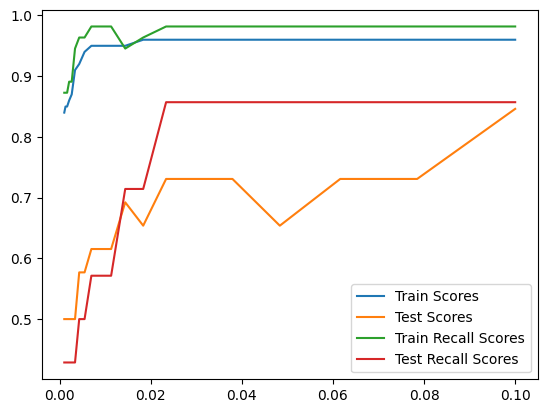

In [64]:
plt.plot(10**np.linspace(-3,-1,20), train_scores, label='Train Scores')
plt.plot(10**np.linspace(-3,-1,20), test_scores, label='Test Scores')
plt.plot(10**np.linspace(-3,-1,20), train_recall, label='Train Recall Scores')
plt.plot(10**np.linspace(-3,-1,20), test_recall, label='Test Recall Scores')
plt.legend()
plt.show()

Looping through small values up to the default value of the learning rate we can see that the default value of .1 for the learning rate is adequate enough to provide good results across all metrics.

In [65]:
sgd_tuned = SGD(random_state=seed,
                n_estimators=1000,
                learning_rate=0.1,
                max_depth=4)
sgd_tuned.fit(X_train, y_train)

return_scores(sgd_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.960000,0.981818,0.947368
Test,0.846154,0.857143,0.857143


In [66]:
df = pd.DataFrame({
    'Importance': sgd_tuned.feature_importances_
}, index=X_train.columns).sort_values(by='Importance', ascending=True)

df

,Importance
I paid good price for my order,0.071278
I am satisfied with my courier,0.141884
contents of my order was as I expected,0.142503
the app makes ordering easy,0.180368
I ordered everything I wanted to order,0.206331
my order was delivered on time,0.257636


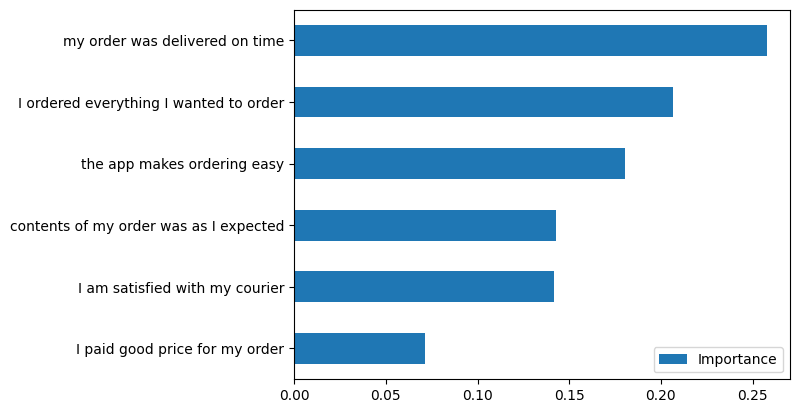

In [67]:
df.plot(kind='barh')
plt.show()

In [56]:
import pathlib

path = pathlib.Path('../../feature importances/sgd_features.csv')

if path.exists() != True:
    df.to_csv(path)

### XGBoost

In [68]:
## default values

xgb_classifier = XGB.XGBClassifier(random_state=seed,
                                   objective='binary:logistic',
                                   n_estimators=1000,
                                   verbosity=1,
                                   learning_rate=.3
                                   )

xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, random_state=5249, ...)

In [69]:
return_scores(xgb_classifier, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.950000,0.981818,0.931034
Test,0.692308,0.642857,0.750000


In [70]:
eval_set = [(X_train, y_train), (X_test, y_test)]

In [71]:
xgb_classifier2 = XGB.XGBClassifier(random_state=seed,
                                    objective='binary:logistic',
                                    n_estimators=1000,
                                    verbosity=1,
                                    learning_rate=.3,
                                    verbose=True,
                                    eval_metric='error',
                                    early_stopping_rounds=30
                                     ).fit(X_train, y_train,eval_set=eval_set)

return_scores(xgb_classifier2, X_train, X_test, y_train, y_test)

[0]	validation_0-error:0.28000	validation_1-error:0.42308
[1]	validation_0-error:0.21000	validation_1-error:0.38462
[2]	validation_0-error:0.21000	validation_1-error:0.38462
[3]	validation_0-error:0.21000	validation_1-error:0.38462
[4]	validation_0-error:0.22000	validation_1-error:0.42308
[5]	validation_0-error:0.21000	validation_1-error:0.38462
[6]	validation_0-error:0.19000	validation_1-error:0.38462
[7]	validation_0-error:0.20000	validation_1-error:0.46154
[8]	validation_0-error:0.20000	validation_1-error:0.42308
[9]	validation_0-error:0.19000	validation_1-error:0.38462
[10]	validation_0-error:0.18000	validation_1-error:0.38462
[11]	validation_0-error:0.15000	validation_1-error:0.38462
[12]	validation_0-error:0.19000	validation_1-error:0.42308
[13]	validation_0-error:0.18000	validation_1-error:0.38462
[14]	validation_0-error:0.18000	validation_1-error:0.46154
[15]	validation_0-error:0.15000	validation_1-error:0.38462
[16]	validation_0-error:0.16000	validation_1-error:0.38462
[17]	va

,Accuracy,Recall,Precision
Train,0.790000,0.872727,0.774194
Test,0.615385,0.500000,0.700000


In [72]:
xgb_classifier2.get_booster().attributes()

{'best_iteration': '1', 'best_score': '0.38461538461538464'}

The 'error' that is used for eval_metric is 1 - score. Looking at the test score in the table above we see that 1 - .615 = .385.

In [ ]:
test_scores, test_recall = [], []
train_scores, train_recall = [], []
best_iterations = []

for i in 10**np.linspace(-3,-1,20):
    xgb_classifier2.learning_rate = i
    xgb_classifier2.fit(X_train, y_train, eval_set=eval_set, verbose=0)

    # print(f"Learning rate: {i}")
    acc, recall = list(return_scores(xgb_classifier2, X_train, X_test, y_train, y_test).items())[0:2] ## returns tuple of accuracy scores and recall scores

    best_iterations.append(xgb_classifier2.get_booster().attributes()['best_iteration'])
    test_scores.append(acc[1][1])
    test_recall.append(recall[1][1])
    train_scores.append(acc[1][0])
    train_recall.append(recall[1][0])

Learning rate: 0.001


Learning rate: 0.0012742749857031334
Learning rate: 0.001623776739188721
Learning rate: 0.00206913808111479
Learning rate: 0.0026366508987303583
Learning rate: 0.003359818286283781
Learning rate: 0.004281332398719396
Learning rate: 0.00545559478116852
Learning rate: 0.0069519279617756054
Learning rate: 0.008858667904100823
Learning rate: 0.011288378916846888
Learning rate: 0.01438449888287663
Learning rate: 0.018329807108324356
Learning rate: 0.023357214690901212
Learning rate: 0.029763514416313176
Learning rate: 0.0379269019073225
Learning rate: 0.04832930238571752
Learning rate: 0.06158482110660261
Learning rate: 0.07847599703514611
Learning rate: 0.1


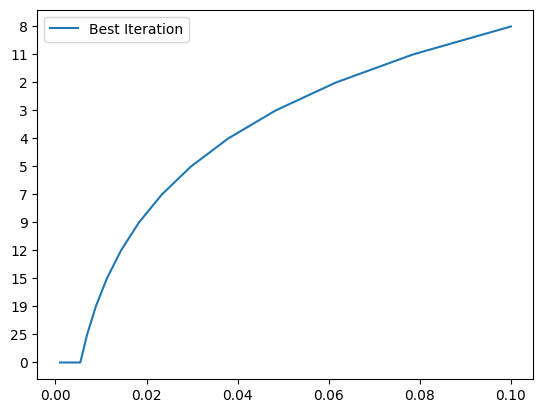

In [ ]:
plt.plot(10**np.linspace(-3,-1,20), best_iterations, label='Best Iteration')
plt.legend()
plt.show()

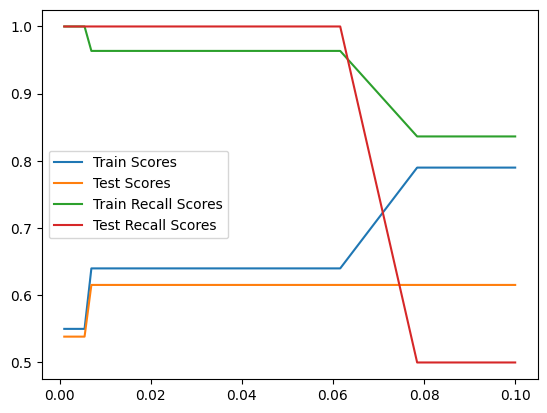

In [62]:
plt.plot(10**np.linspace(-3,-1,20), train_scores, label='Train Scores')
plt.plot(10**np.linspace(-3,-1,20), test_scores, label='Test Scores')
plt.plot(10**np.linspace(-3,-1,20), train_recall, label='Train Recall Scores')
plt.plot(10**np.linspace(-3,-1,20), test_recall, label='Test Recall Scores')
plt.legend()
plt.show()

In [80]:
from scipy.stats import uniform

space = {
    'max_depth': hp.choice('max_depth', [2,3,4,5,6,7]),
    'gamma': hp.choice('gamma', np.arange(.01, 1000, 20)),
    'min_child_weight': hp.choice('min_child_weight', np.arange(1,151)),
    'col_sample_by_tree': hp.choice('col_sample_by_tre', np.linspace(0.0, 1.0, 20)),
    'subsample': hp.choice('subsample', np.linspace(.5, 1.0, 20)),
    # 'learning_rate': hp.choice('learing_rate', 10**np.linspace(-3, -1, 20))
}

def hyperparameter_tuning(space):
    model = xgb_classifier2
    model.set_params(**space)
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train, y_train, eval_set=eval_set)
    
    acc = model.score(X_test, y_test)   
    
    print()
    print(return_scores(model, X_train, X_test, y_train, y_test))
    print({'gamma': space['gamma'],
           'max_depth': space['max_depth'],
        #    'learning_rate': space['learning_rate'],
           'subsample': space['subsample'],
           'min_child_weight': space['min_child_weight'],
           'col_sample_by_tree': space['col_sample_by_tree']
           })

    return {'loss': -acc, 'status': STATUS_OK}

In [81]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning,
            space=space,
            algo=hyperopt.tpe.suggest,
            trials=trials,
            max_evals=100,
            verbose=0)

print(f"\nBest hyperparameter sweep: \n\t{best}")

[0]	validation_0-error:0.45000	validation_1-error:0.46154
[1]	validation_0-error:0.45000	validation_1-error:0.46154
[2]	validation_0-error:0.45000	validation_1-error:0.46154
[3]	validation_0-error:0.45000	validation_1-error:0.46154
[4]	validation_0-error:0.45000	validation_1-error:0.46154
[5]	validation_0-error:0.45000	validation_1-error:0.46154
[6]	validation_0-error:0.45000	validation_1-error:0.46154
[7]	validation_0-error:0.45000	validation_1-error:0.46154
[8]	validation_0-error:0.45000	validation_1-error:0.46154
[9]	validation_0-error:0.45000	validation_1-error:0.46154
[10]	validation_0-error:0.45000	validation_1-error:0.46154
[11]	validation_0-error:0.45000	validation_1-error:0.46154
[12]	validation_0-error:0.45000	validation_1-error:0.46154
[13]	validation_0-error:0.45000	validation_1-error:0.46154
[14]	validation_0-error:0.45000	validation_1-error:0.46154
[15]	validation_0-error:0.45000	validation_1-error:0.46154
[16]	validation_0-error:0.45000	validation_1-error:0.46154
[17]	va

In [ ]:
## grow_policy

xgb_hist = XGB.XGBClassifier(n_estimatros=1000,
                             max_depth=0,
                             learning_rate=.1,
                             objective='binary:logistic',
                             n_jobs=-1,
                             tree_method='hist',
                             grow_policy='lossguide',
                             verbose=0)

In [88]:
test_scores, test_recall = [], []
train_scores, train_recall = [], []

for leaf in np.arange(5,105,5):
    xgb_hist.max_leaves = leaf
    xgb_hist.fit(X_train, y_train, eval_set=eval_set, verbose=0)

    acc, recall = list(return_scores(xgb_hist, X_train, X_test, y_train, y_test).items())[0:2] ## returns tuple of accuracy scores and recall scores

    test_scores.append(acc[1][1])
    test_recall.append(recall[1][1])
    train_scores.append(acc[1][0])
    train_recall.append(recall[1][0])

    if leaf % 10:
        print(f"Done with leaf: {leaf}")


Done with leaf: 5
Done with leaf: 15
Done with leaf: 25
Done with leaf: 35
Done with leaf: 45
Done with leaf: 55
Done with leaf: 65
Done with leaf: 75
Done with leaf: 85
Done with leaf: 95


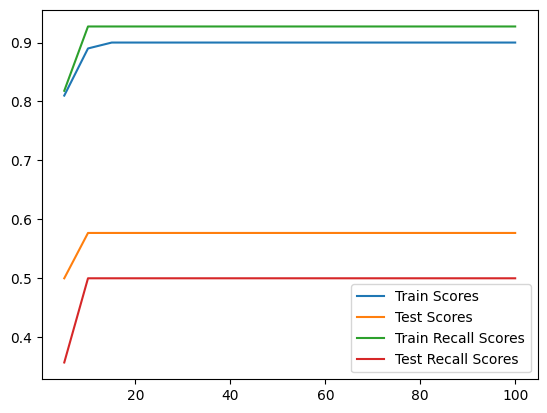

In [89]:
plt.plot(np.arange(5,105,5), train_scores, label='Train Scores')
plt.plot(np.arange(5,105,5), test_scores, label='Test Scores')
plt.plot(np.arange(5,105,5), train_recall, label='Train Recall Scores')
plt.plot(np.arange(5,105,5), test_recall, label='Test Recall Scores')
plt.legend()
plt.show()

In [90]:
xgb_hist = XGB.XGBClassifier(n_estimatros=1000,
                             max_depth=0,
                             learning_rate=.1,
                             objective='binary:logistic',
                             n_jobs=-1,
                             tree_method='hist',
                             grow_policy='lossguide',
                             verbose=0,
                             max_leaves=10)

xgb_hist.fit(X_train, y_train, eval_set=eval_set, verbose=0)

return_scores(xgb_hist, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.890000,0.927273,0.879310
Test,0.576923,0.500000,0.636364


In [91]:
return_scores(xgb_classifier, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.950000,0.981818,0.931034
Test,0.692308,0.642857,0.750000


In [92]:
importances = pd.DataFrame({
    'Importance': xgb_classifier.feature_importances_
}, index=X_train.columns).sort_values(by='Importance', ascending=True)

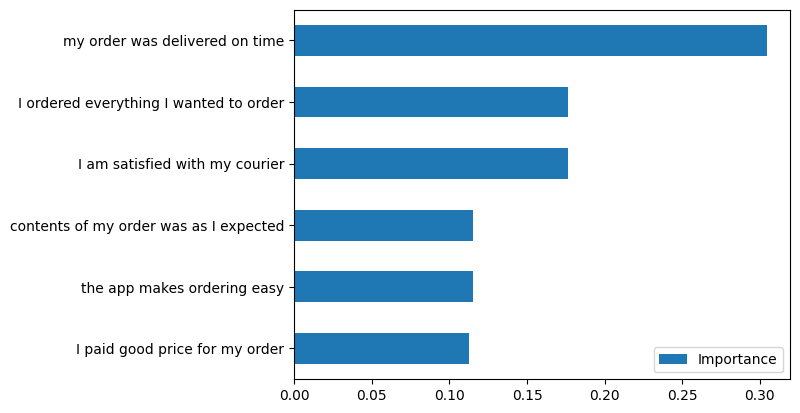

In [93]:
importances.plot(kind='barh')
plt.show()

In [94]:
return_scores(xgb_classifier, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.950000,0.981818,0.931034
Test,0.692308,0.642857,0.750000


In [95]:
return_scores(sgd_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.960000,0.981818,0.947368
Test,0.846154,0.857143,0.857143


Looking at the Stochastic Gradient Descent model and the XGBoost model, the tuned SGD model performs well along all our metrics and will be the model we will use going forward to identify customer satisfaction.

Look to features.ipynb for features identified by top models experimented with as well as performance on the model with whole dataset!!

In [102]:
import pickle

with open('data.pkl', 'wb') as f:
    pickle.dump([X_train, X_test, y_train, y_test, sgd_tuned], f)